In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
import os
import time
import json
from datetime import datetime, timedelta
from collections import Counter
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
os.makedirs('output', exist_ok=True)

In [3]:
# ── Preprocessing ────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.pipeline import Pipeline


In [4]:
# ── Imbalance Handling ───────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
    from imblearn.under_sampling import RandomUnderSampler, TomekLinks
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("Install: pip install imbalanced-learn")


In [5]:

# Traditional ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               IsolationForest, VotingClassifier)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM


In [6]:
# — Deep Learning models
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
except (ImportError, TypeError, Exception) as e:
    TF_AVAILABLE = False
    print(f"TensorFlow not available: {e}")

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except (ImportError, Exception) as e:
    XGB_AVAILABLE = False
    print(f"XGBoost not available: {e}")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except (ImportError, Exception) as e:
    LGB_AVAILABLE = False
    print(f"LightGBM not available: {e}")

In [7]:

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, auc,
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, fbeta_score
)


In [8]:

# Explainability 
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("Install: pip install shap")

# Stats models
from scipy import stats
from scipy.stats import mannwhitneyu, ks_2samp

# Cost constants (realistic fraud costs)
FRAUD_LOSS_AVG        = 122.21   # Average transaction amount in dataset
FALSE_POSITIVE_COST   = 15.00    # Customer service cost for blocked legit txn
FALSE_NEGATIVE_COST   = FRAUD_LOSS_AVG  # Avg fraud amount lost
INVESTIGATION_COST    = 5.00     # Cost to investigate flagged transaction

print("Setup complete. All imports loaded.")


Install: pip install shap
Setup complete. All imports loaded.


In [9]:
print("\n" + "="*60)
print("SECTION 1: LOAD DATA & INITIAL EXPLORATION")
print("="*60)

df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")
print(f"\nStatistical summary:")
print(df[['Time', 'Amount', 'Class']].describe())



SECTION 1: LOAD DATA & INITIAL EXPLORATION
Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:
    Time      V1      V2     V3      V4      V5      V6      V7      V8  \
0 0.0000 -1.3598 -0.0728 2.5363  1.3782 -0.3383  0.4624  0.2396  0.0987   
1 0.0000  1.1919  0.2662 0.1665  0.4482  0.0600 -0.0824 -0.0788  0.0851   
2 1.0000 -1.3584 -1.3402 1.7732  0.3798 -0.5032  1.8005  0.7915  0.2477   
3 1.0000 -0.9663 -0.1852 1.7930 -0.8633 -0.0103  1.2472  0.2376  0.3774   
4 2.0000 -1.1582  0.8777 1.5487  0.4030 -0.4072  0.0959  0.5929 -0.2705   

       V9     V10     V11     V12     V13     V14     V15     V16     V17  \
0  0.3638  0.0908 -0.5516 -0.6178 -0.9914 -0.3112  1.4682 -0.4704  0.2080   
1 -0.2554 -0.1670  1.6127  1.0652  0.4891 -0.1438  0.6356  0.4639 -0.1148   
2 -1.51


SECTION 2: THE ACCURACY PARADOX DEMONSTRATION

Total transactions:     284,807
Fraud transactions:     492
Legitimate transactions:284,315
Fraud rate:             0.1727%

── Naive Model (always predicts NOT FRAUD) ──────────────
Accuracy:  99.83%  ← MISLEADINGLY HIGH
Precision: 0.00%  ← Catches NO fraud
Recall:    0.00%  ← Catches NO fraud
F1 Score:  0.00%
Financial Loss: £60,127.32 (all fraud undetected)

── Why We Use Precision-Recall AUC Instead ──────────────
Precision = Of all flagged transactions, how many are truly fraud?
Recall    = Of all fraud transactions, how many did we catch?
PR-AUC    = Area under Precision-Recall curve — accounts for imbalance
F-beta    = Weighted F score — when recall matters more than precision


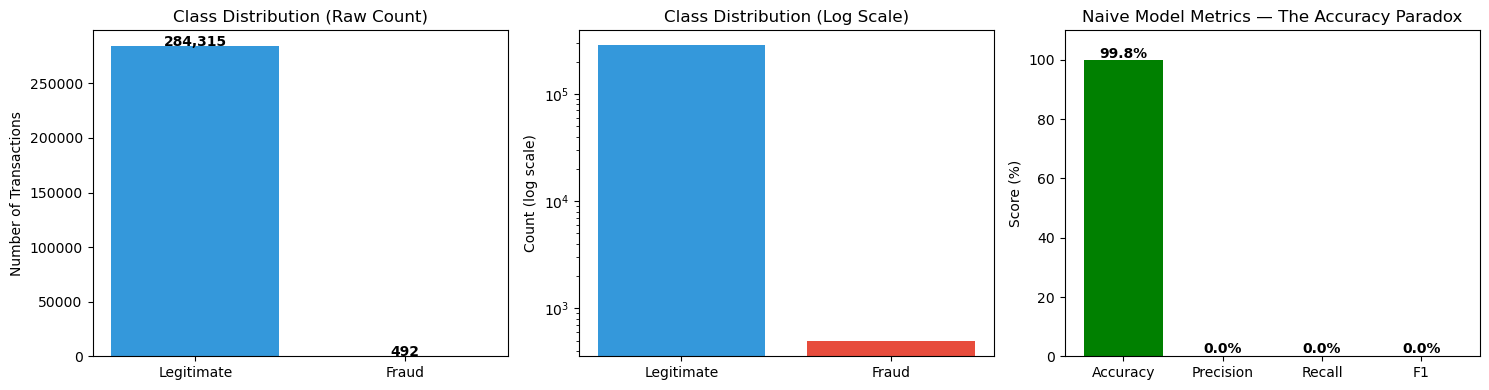

Saved: accuracy_paradox.png


In [10]:
# Demonstration of the accuracy paradox explicitly

print("\n" + "="*60)
print("SECTION 2: THE ACCURACY PARADOX DEMONSTRATION")
print("="*60)

total         = len(df)
fraud_count   = df['Class'].sum()
legit_count   = total - fraud_count
fraud_rate    = fraud_count / total

print(f"\nTotal transactions:     {total:,}")
print(f"Fraud transactions:     {fraud_count:,}")
print(f"Legitimate transactions:{legit_count:,}")
print(f"Fraud rate:             {fraud_rate*100:.4f}%")

# A naive model that ALWAYS predicts 'Not Fraud'
naive_accuracy = legit_count / total
naive_precision = 0   # Never predicts fraud, so precision undefined
naive_recall    = 0   # Catches 0 fraud cases

print(f"\n── Naive Model (always predicts NOT FRAUD) ──────────────")
print(f"Accuracy:  {naive_accuracy*100:.2f}%  ← MISLEADINGLY HIGH")
print(f"Precision: {naive_precision*100:.2f}%  ← Catches NO fraud")
print(f"Recall:    {naive_recall*100:.2f}%  ← Catches NO fraud")
print(f"F1 Score:  0.00%")
print(f"Financial Loss: £{fraud_count * FALSE_NEGATIVE_COST:,.2f} (all fraud undetected)")

print(f"\n── Why We Use Precision-Recall AUC Instead ──────────────")
print(f"Precision = Of all flagged transactions, how many are truly fraud?")
print(f"Recall    = Of all fraud transactions, how many did we catch?")
print(f"PR-AUC    = Area under Precision-Recall curve — accounts for imbalance")
print(f"F-beta    = Weighted F score — when recall matters more than precision")

# Visualize the imbalance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
axes[0].bar(['Legitimate', 'Fraud'],
            [legit_count, fraud_count],
            color=['#3498DB', '#E74C3C'])
axes[0].set_title('Class Distribution (Raw Count)')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate([legit_count, fraud_count]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Log scale
axes[1].bar(['Legitimate', 'Fraud'],
            [legit_count, fraud_count],
            color=['#3498DB', '#E74C3C'])
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_ylabel('Count (log scale)')

# Accuracy paradox comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
naive   = [99.83, 0, 0, 0]
axes[2].bar(metrics, naive, color=['green', 'red', 'red', 'red'])
axes[2].set_title('Naive Model Metrics — The Accuracy Paradox')
axes[2].set_ylabel('Score (%)')
axes[2].set_ylim(0, 110)
for i, v in enumerate(naive):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('output/accuracy_paradox.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: accuracy_paradox.png")




SECTION 3: EXPLORATORY DATA ANALYSIS

Amount Statistics by Class:
               mean  median      std        max    min
Legitimate  88.2900 22.0000 250.1100 25691.1600 0.0000
Fraud      122.2100  9.2500 256.6800  2125.8700 0.0000


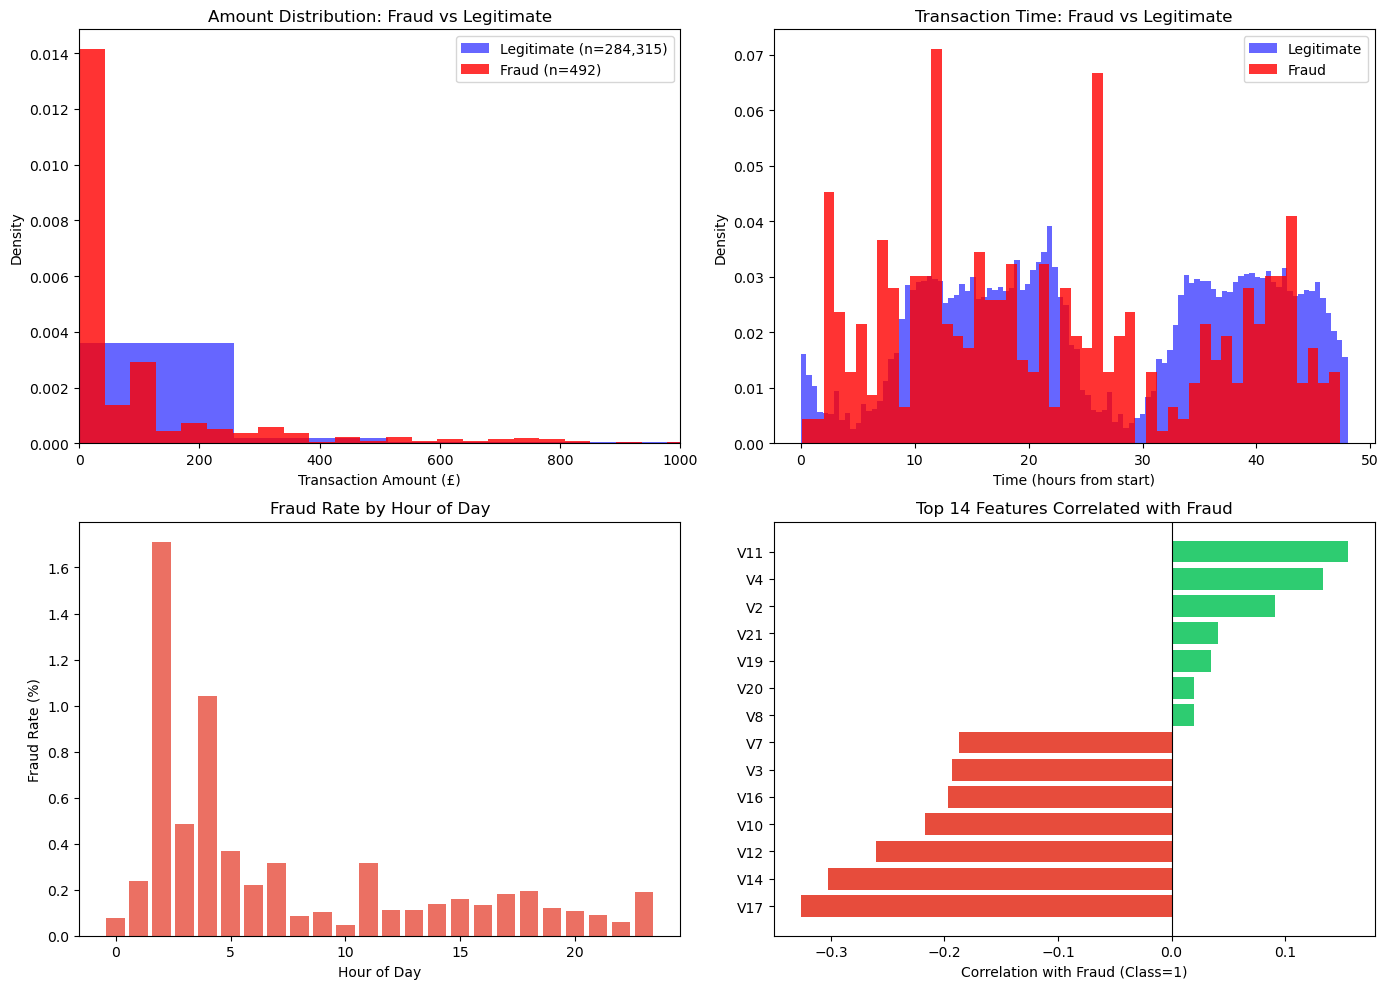


── KS Test: Feature Distribution Differences (Fraud vs Legit) ──
Feature  KS_Statistic  P_Value  Significant
    V14        0.8428   0.0000         True
    V10        0.8043   0.0000         True
    V12        0.7839   0.0000         True
     V4        0.7664   0.0000         True
    V11        0.7561   0.0000         True
    V17        0.7452   0.0000         True
     V3        0.7037   0.0000         True
    V16        0.6865   0.0000         True
     V7        0.6606   0.0000         True
     V2        0.6332   0.0000         True
     V9        0.5763   0.0000         True
    V21        0.5185   0.0000         True
    V18        0.5034   0.0000         True
     V6        0.4864   0.0000         True
     V1        0.4753   0.0000         True
    V27        0.4695   0.0000         True
     V5        0.4364   0.0000         True
    V28        0.3685   0.0000         True
     V8        0.3684   0.0000         True
    V20        0.3639   0.0000         True
    V19   

In [11]:
# EDA
print("\n" + "="*60)
print("SECTION 3: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Amount distribution by class 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']
axes[0, 0].hist(legit, bins=100, alpha=0.6, color='blue',
                label=f'Legitimate (n={len(legit):,})', density=True)
axes[0, 0].hist(fraud, bins=50, alpha=0.8, color='red',
                label=f'Fraud (n={len(fraud):,})', density=True)
axes[0, 0].set_xlabel('Transaction Amount (£)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Amount Distribution: Fraud vs Legitimate')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 1000)

# Amount statistics comparison
amount_stats = df.groupby('Class')['Amount'].agg(
    ['mean', 'median', 'std', 'max', 'min']
).round(2)
amount_stats.index = ['Legitimate', 'Fraud']
print("\nAmount Statistics by Class:")
print(amount_stats)

# Time distribution
axes[0, 1].hist(df[df['Class']==0]['Time']/3600, bins=100,
                alpha=0.6, color='blue', label='Legitimate', density=True)
axes[0, 1].hist(df[df['Class']==1]['Time']/3600, bins=50,
                alpha=0.8, color='red', label='Fraud', density=True)
axes[0, 1].set_xlabel('Time (hours from start)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Transaction Time: Fraud vs Legitimate')
axes[0, 1].legend()

# Fraud rate by time window
df['Hour'] = (df['Time'] // 3600) % 24
hourly_fraud = df.groupby('Hour').agg(
    Total=('Class', 'count'),
    Fraud=('Class', 'sum')
)
hourly_fraud['Fraud_Rate'] = hourly_fraud['Fraud'] / hourly_fraud['Total'] * 100

axes[1, 0].bar(hourly_fraud.index, hourly_fraud['Fraud_Rate'],
               color='#E74C3C', alpha=0.8)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Fraud Rate (%)')
axes[1, 0].set_title('Fraud Rate by Hour of Day')

# Correlation of features with fraud
feature_cols = [c for c in df.columns if c.startswith('V')]
correlations = df[feature_cols + ['Class']].corr()['Class'].drop('Class').sort_values()
top_corr = pd.concat([correlations.head(7), correlations.tail(7)])
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in top_corr.values]
axes[1, 1].barh(top_corr.index, top_corr.values, color=colors)
axes[1, 1].set_xlabel('Correlation with Fraud (Class=1)')
axes[1, 1].set_title('Top 14 Features Correlated with Fraud')
axes[1, 1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('output/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# KS Test: Are features statistically different between classes
print("\n── KS Test: Feature Distribution Differences (Fraud vs Legit) ──")
ks_results = []
for col in feature_cols + ['Amount']:
    fraud_vals = df[df['Class'] == 1][col]
    legit_vals = df[df['Class'] == 0][col]
    stat, p = ks_2samp(fraud_vals, legit_vals)
    ks_results.append({'Feature': col, 'KS_Statistic': stat, 'P_Value': p,
                       'Significant': p < 0.05})

ks_df = pd.DataFrame(ks_results).sort_values('KS_Statistic', ascending=False)
print(ks_df.to_string(index=False))
print(f"\nFeatures significantly different between classes: "
      f"{ks_df['Significant'].sum()} / {len(ks_df)}")


In [12]:
# Feature Engineering
print("\n" + "="*60)
print("SECTION 4: ADVANCED FEATURE ENGINEERING")
print("="*60)

df_eng = df.copy()

# Time-based features 
df_eng['Hour']          = (df_eng['Time'] // 3600) % 24
df_eng['Is_Night']      = ((df_eng['Hour'] >= 22) | (df_eng['Hour'] <= 5)).astype(int)
df_eng['Is_Rush_Hour']  = ((df_eng['Hour'].between(7, 9)) |
                            (df_eng['Hour'].between(17, 19))).astype(int)
df_eng['Day_Number']    = (df_eng['Time'] // 86400).astype(int)  # Day 0 or 1

# Amount-based features
df_eng['Amount_Log']    = np.log1p(df_eng['Amount'])
df_eng['Amount_Squared']= df_eng['Amount'] ** 2
df_eng['Is_Round_Amount']= (df_eng['Amount'] % 1 == 0).astype(int)
df_eng['Is_Small_Amount']= (df_eng['Amount'] < 1).astype(int)  # Micro-test transactions

# ── Statistical aggregation features (rolling z-score of amount) ──
# Sort by time first
df_eng = df_eng.sort_values('Time').reset_index(drop=True)
df_eng['Amount_Rolling_Mean'] = df_eng['Amount'].rolling(window=100, min_periods=1).mean()
df_eng['Amount_Rolling_Std']  = df_eng['Amount'].rolling(window=100, min_periods=1).std().fillna(1)
df_eng['Amount_ZScore']       = (
    (df_eng['Amount'] - df_eng['Amount_Rolling_Mean'])
    / df_eng['Amount_Rolling_Std']
)

# PCA component interactions (top correlated) 
# From KS test, V17, V14, V12, V10 most differentiating
df_eng['V17_V14_interaction'] = df_eng['V17'] * df_eng['V14']
df_eng['V17_Amount_ratio']    = df_eng['V17'] / (df_eng['Amount'] + 1)
df_eng['V14_V12_interaction'] = df_eng['V14'] * df_eng['V12']

print(f"Original features:     {df.shape[1]}")
print(f"Engineered features:   {df_eng.shape[1]}")
print(f"\nNew features added:")
new_features = [c for c in df_eng.columns if c not in df.columns]
for f in new_features:
    print(f"  + {f}")

# Validate new features separate classes
print("\n── New Feature Statistics by Class ──")
for feat in ['Amount_Log', 'Is_Night', 'Is_Small_Amount', 'Amount_ZScore']:
    fraud_mean = df_eng[df_eng['Class']==1][feat].mean()
    legit_mean = df_eng[df_eng['Class']==0][feat].mean()
    print(f"  {feat}: Fraud={fraud_mean:.3f}, Legit={legit_mean:.3f}, "
          f"Diff={abs(fraud_mean-legit_mean):.3f}")



SECTION 4: ADVANCED FEATURE ENGINEERING
Original features:     32
Engineered features:   45

New features added:
  + Is_Night
  + Is_Rush_Hour
  + Day_Number
  + Amount_Log
  + Amount_Squared
  + Is_Round_Amount
  + Is_Small_Amount
  + Amount_Rolling_Mean
  + Amount_Rolling_Std
  + Amount_ZScore
  + V17_V14_interaction
  + V17_Amount_ratio
  + V14_V12_interaction

── New Feature Statistics by Class ──
  Amount_Log: Fraud=2.821, Legit=3.153, Diff=0.332
  Is_Night: Fraud=0.313, Legit=0.176, Diff=0.137
  Is_Small_Amount: Fraud=0.138, Legit=0.059, Diff=0.079
  Amount_ZScore: Fraud=0.195, Legit=0.000, Diff=0.195


In [13]:
print("\n" + "="*60)
print("SECTION 5: RULE-BASED DETECTION — PHILOSOPHY 1")
print("="*60)

def rule_based_detector(row):
    """
    Explicit business rule fraud detector.
    Returns 1 (fraud) or 0 (legit) based on domain rules.
    """
    flags = 0
    reasons = []

    # Rule 1: Small test amount followed by larger transaction pattern
    if row['Amount'] < 1.0:
        flags += 1
        reasons.append("Micro-test transaction (<£1)")

    # Rule 2: Suspicious hour
    hour = int((row['Time'] // 3600) % 24)
    if hour >= 23 or hour <= 4:
        flags += 1
        reasons.append(f"Night-time transaction (hour={hour})")

    # Rule 3: High-value transaction
    if row['Amount'] > 1000:
        flags += 1
        reasons.append(f"High-value transaction (£{row['Amount']:.2f})")

    # Rule 4: Key PCA features outside normal range
    if row['V14'] < -5:
        flags += 2
        reasons.append(f"V14 anomaly ({row['V14']:.2f})")

    if row['V17'] < -5:
        flags += 2
        reasons.append(f"V17 anomaly ({row['V17']:.2f})")

    if row['V10'] < -5:
        flags += 1
        reasons.append(f"V10 anomaly ({row['V10']:.2f})")

    return 1 if flags >= 2 else 0

print("Applying rule-based detection...")
t0 = time.time()
df_eng['Rule_Pred'] = df_eng.apply(rule_based_detector, axis=1)
t_rule = time.time() - t0

# Evaluate rules
rule_pr_auc = average_precision_score(df_eng['Class'], df_eng['Rule_Pred'])
rule_cm     = confusion_matrix(df_eng['Class'], df_eng['Rule_Pred'])
rule_recall = recall_score(df_eng['Class'], df_eng['Rule_Pred'])
rule_prec   = precision_score(df_eng['Class'], df_eng['Rule_Pred'],
                               zero_division=0)

print(f"\nRule-Based Detector Results:")
print(f"  Precision-Recall AUC: {rule_pr_auc:.4f}")
print(f"  Recall (fraud caught): {rule_recall*100:.1f}%")
print(f"  Precision:             {rule_prec*100:.1f}%")
print(f"  Processing time:       {t_rule:.2f}s")
print(f"  Confusion Matrix:\n{rule_cm}")

# Financial cost of rule-based
rule_fn = rule_cm[1][0]  # Missed fraud (false negatives)
rule_fp = rule_cm[0][1]  # False alarms (false positives)
rule_cost = (rule_fn * FALSE_NEGATIVE_COST) + (rule_fp * FALSE_POSITIVE_COST)
print(f"\n  Financial Cost (Rule-Based):")
print(f"  Missed fraud: {rule_fn} × £{FALSE_NEGATIVE_COST:.2f} = "
      f"£{rule_fn*FALSE_NEGATIVE_COST:,.2f}")
print(f"  False alarms: {rule_fp} × £{FALSE_POSITIVE_COST:.2f} = "
      f"£{rule_fp*FALSE_POSITIVE_COST:,.2f}")
print(f"  TOTAL COST:   £{rule_cost:,.2f}")
print(f"\nLimitation: Rules are static, brittle, and miss novel fraud patterns")



SECTION 5: RULE-BASED DETECTION — PHILOSOPHY 1
Applying rule-based detection...



Rule-Based Detector Results:
  Precision-Recall AUC: 0.0955
  Recall (fraud caught): 76.0%
  Precision:             12.5%
  Processing time:       3.06s
  Confusion Matrix:
[[281698   2617]
 [   118    374]]

  Financial Cost (Rule-Based):
  Missed fraud: 118 × £122.21 = £14,420.78
  False alarms: 2617 × £15.00 = £39,255.00
  TOTAL COST:   £53,675.78

Limitation: Rules are static, brittle, and miss novel fraud patterns


In [14]:
print("\n" + "="*60)
print("SECTION 6: DATA PREPARATION — SCALING & SPLITTING")
print("="*60)

feature_cols_ml = ([c for c in df_eng.columns if c.startswith('V')] +
                   ['Amount_Log', 'Hour', 'Is_Night', 'Is_Rush_Hour',
                    'Is_Round_Amount', 'Is_Small_Amount', 'Amount_ZScore',
                    'V17_V14_interaction', 'V17_Amount_ratio', 'V14_V12_interaction'])

X = df_eng[feature_cols_ml].fillna(0)
y = df_eng['Class']

# Stratified split preserves fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test set:     {X_test.shape}  | Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

# RobustScaler is better than StandardScaler for fraud data
# — less sensitive to outliers in Amount
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nUsing RobustScaler (not StandardScaler) — reason:")
print(f"Amount has extreme outliers (max=£{df['Amount'].max():.0f})")
print(f"RobustScaler uses median and IQR instead of mean and std")
print(f"→ Outliers have less influence on scaling")



SECTION 6: DATA PREPARATION — SCALING & SPLITTING
Training set: (227845, 41) | Fraud: 394 (0.173%)
Test set:     (56962, 41)  | Fraud: 98 (0.172%)

Using RobustScaler (not StandardScaler) — reason:
Amount has extreme outliers (max=£25691)
RobustScaler uses median and IQR instead of mean and std
→ Outliers have less influence on scaling


In [ ]:
print("\n" + "="*60)
print("SECTION 7: IMBALANCE HANDLING STRATEGY COMPARISON")
print("="*60)

if IMBLEARN_AVAILABLE:
    strategies = {
        'No Resampling': (X_train_scaled, y_train),
    }

    # SMOTE
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_sm, y_sm = sm.fit_resample(X_train_scaled, y_train)
    strategies['SMOTE'] = (X_sm, y_sm)

    # BorderlineSMOTE
    bsm = BorderlineSMOTE(random_state=42)
    X_bsm, y_bsm = bsm.fit_resample(X_train_scaled, y_train)
    strategies['BorderlineSMOTE'] = (X_bsm, y_bsm)

    # ADASYN
    ada = ADASYN(random_state=42)
    X_ada, y_ada = ada.fit_resample(X_train_scaled, y_train)
    strategies['ADASYN'] = (X_ada, y_ada)

    # SMOTETomek (combined over+under sampling)
    smt = SMOTETomek(random_state=42)
    X_smt, y_smt = smt.fit_resample(X_train_scaled, y_train)
    strategies['SMOTETomek'] = (X_smt, y_smt)

    print("\nResampled dataset sizes:")
    for name, (Xs, ys) in strategies.items():
        fraud_n = ys.sum() if hasattr(ys, 'sum') else sum(ys)
        total_n = len(ys)
        print(f"  {name}: Total={total_n:,} | Fraud={fraud_n:,} "
              f"({fraud_n/total_n*100:.1f}%)")

    # Quick evaluation of each strategy with Logistic Regression
    print("\nLogistic Regression PR-AUC by resampling strategy:")
    strategy_results = {}
    for name, (Xs, ys) in strategies.items():
        lr = LogisticRegression(max_iter=500, random_state=42,
                                class_weight='balanced')
        lr.fit(Xs, ys)
        proba = lr.predict_proba(X_test_scaled)[:, 1]
        pr_auc = average_precision_score(y_test, proba)
        strategy_results[name] = pr_auc
        print(f"  {name}: PR-AUC = {pr_auc:.4f}")

    best_strategy = max(strategy_results, key=strategy_results.get)
    print(f"\nBest resampling strategy: {best_strategy}")

    # Use SMOTE for remaining analysis
    X_train_res, y_train_res = strategies.get('SMOTE', (X_train_scaled, y_train))
else:
    X_train_res, y_train_res = X_train_scaled, y_train
    print("Using class_weight='balanced' as imbalance handling")



SECTION 7: IMBALANCE HANDLING STRATEGY COMPARISON


  File "d:\Documents\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\Documents\anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Documents\anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Documents\anaconda\Lib\subprocess.py", line 15

In [ ]:
print("\n" + "="*60)
print("SECTION 8: TRADITIONAL ML DETECTION — PHILOSOPHY 2")
print("="*60)

# Unsupervised Anomaly Detection
print("\n── Unsupervised Anomaly Detectors ────────────────────────")

# Use only legitimate training data for unsupervised methods
X_train_legit = X_train_scaled[y_train == 0]

models_unsupervised = {}

# Isolation Forest
t0 = time.time()
iso = IsolationForest(n_estimators=200, contamination=fraud_rate,
                      random_state=42, n_jobs=-1)
iso.fit(X_train_legit)
iso_scores = -iso.score_samples(X_test_scaled)  # Higher = more anomalous
iso_preds  = (iso.predict(X_test_scaled) == -1).astype(int)
t_iso = time.time() - t0
models_unsupervised['Isolation Forest'] = {
    'scores': iso_scores, 'preds': iso_preds, 'time': t_iso
}

# Local Outlier Factor
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=fraud_rate,
                          novelty=True, n_jobs=-1)
lof.fit(X_train_legit)
lof_scores = -lof.score_samples(X_test_scaled)
lof_preds  = (lof.predict(X_test_scaled) == -1).astype(int)
t_lof = time.time() - t0
models_unsupervised['Local Outlier Factor'] = {
    'scores': lof_scores, 'preds': lof_preds, 'time': t_lof
}

# One-Class SVM (sample for speed)
sample_idx = np.random.choice(len(X_train_legit),
                               min(5000, len(X_train_legit)), replace=False)
t0 = time.time()
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=fraud_rate)
ocsvm.fit(X_train_legit[sample_idx])
ocsvm_scores = -ocsvm.score_samples(X_test_scaled)
ocsvm_preds  = (ocsvm.predict(X_test_scaled) == -1).astype(int)
t_ocsvm = time.time() - t0
models_unsupervised['One-Class SVM'] = {
    'scores': ocsvm_scores, 'preds': ocsvm_preds, 'time': t_ocsvm
}

print(f"\n{'Model':<25} {'PR-AUC':>8} {'Recall':>8} {'Precision':>10} {'Time':>8}")
print("-" * 65)
unsup_results = {}
for name, m in models_unsupervised.items():
    pr_auc = average_precision_score(y_test, m['scores'])
    rec    = recall_score(y_test, m['preds'])
    prec   = precision_score(y_test, m['preds'], zero_division=0)
    t      = m['time']
    print(f"{name:<25} {pr_auc:>8.4f} {rec:>8.4f} {prec:>10.4f} {t:>6.2f}s")
    unsup_results[name] = {'pr_auc': pr_auc, 'recall': rec, 'precision': prec}

# Supervised ML Models 
print("\n── Supervised ML Models ──────────────────────────────────")

models_supervised = {}

# Logistic Regression
t0 = time.time()
lr  = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train_res, y_train_res)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
t_lr = time.time() - t0
models_supervised['Logistic Regression'] = {
    'model': lr, 'proba': lr_proba, 'time': t_lr
}

# Random Forest
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
t_rf = time.time() - t0
models_supervised['Random Forest'] = {
    'model': rf, 'proba': rf_proba, 'time': t_rf
}

# XGBoost
if XGB_AVAILABLE:
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    t0 = time.time()
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, eval_metric='aucpr',
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train_scaled, y_train,
                  eval_set=[(X_test_scaled, y_test)],
                  verbose=False)
    xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    t_xgb = time.time() - t0
    models_supervised['XGBoost'] = {
        'model': xgb_model, 'proba': xgb_proba, 'time': t_xgb
    }

# LightGBM
if LGB_AVAILABLE:
    t0 = time.time()
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        class_weight='balanced', random_state=42, n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_train_scaled, y_train)
    lgb_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
    t_lgb = time.time() - t0
    models_supervised['LightGBM'] = {
        'model': lgb_model, 'proba': lgb_proba, 'time': t_lgb
    }

print(f"\n{'Model':<25} {'PR-AUC':>8} {'ROC-AUC':>9} {'Time':>8}")
print("-" * 55)
sup_results = {}
for name, m in models_supervised.items():
    pr_auc  = average_precision_score(y_test, m['proba'])
    roc_auc = roc_auc_score(y_test, m['proba'])
    t       = m['time']
    print(f"{name:<25} {pr_auc:>8.4f} {roc_auc:>9.4f} {t:>6.2f}s")
    sup_results[name] = {'pr_auc': pr_auc, 'roc_auc': roc_auc}



SECTION 8: TRADITIONAL ML DETECTION — PHILOSOPHY 2

── Unsupervised Anomaly Detectors ────────────────────────

Model                       PR-AUC   Recall  Precision     Time
-----------------------------------------------------------------
Isolation Forest            0.2463   0.4796     0.2781   3.63s
Local Outlier Factor        0.0505   0.1122     0.1019  67.92s
One-Class SVM               0.3342   0.9286     0.0111   4.12s

── Supervised ML Models ──────────────────────────────────

Model                       PR-AUC   ROC-AUC     Time
-------------------------------------------------------
Logistic Regression         0.7107    0.9713   5.18s
Random Forest               0.8206    0.9779  86.55s
XGBoost                     0.8728    0.9765   7.89s
LightGBM                    0.8824    0.9793   2.43s



SECTION 9: AUTOENCODER ANOMALY DETECTION — PHILOSOPHY 3


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           462 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,639 (14.21 KB)

 Trainable params: 3,639 (14.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 3.5028 - val_loss: 1.0854
Epoch 2/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.8025 - val_loss: 0.9142
Epoch 3/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6539 - val_loss: 0.8309
Epoch 4/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.5878 - val_loss: 0.8198
Epoch 5/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.4579 - val_loss: 0.7850
Epoch 6/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.4600 - val_loss: 0.8383
Epoch 7/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.4765 - val_loss: 0.7209
Epoch 8/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3586 - val_loss: 0.6998
Epoch 9/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.5169 - val_loss: 0.6868
Epoch 10/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.2827 - val_loss: 0.6799
Epoch 11/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3183 - val_loss: 0.6676
Epoch 12/30
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

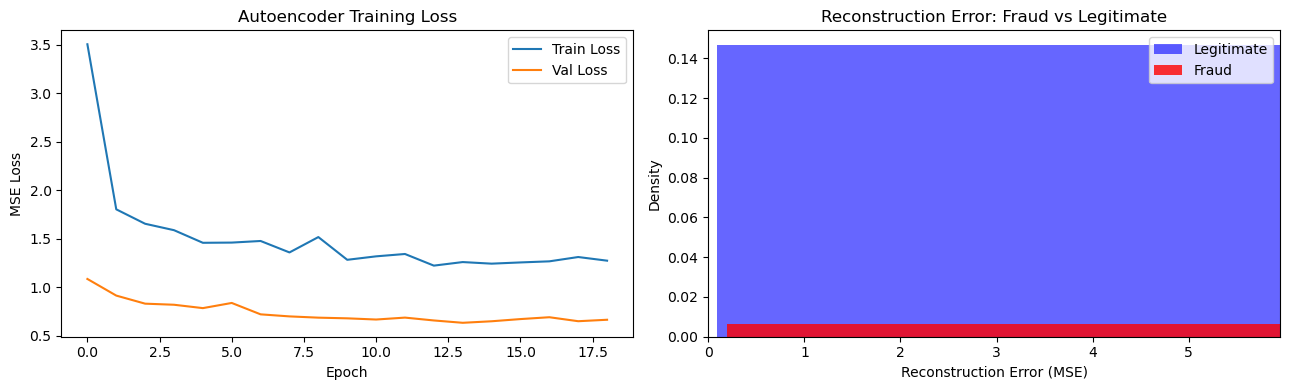


Optimal Threshold: 106.6748
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.46      0.59        98

    accuracy                           1.00     56962
   macro avg       0.91      0.73      0.79     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
print("\n" + "="*60)
print("SECTION 9: AUTOENCODER ANOMALY DETECTION — PHILOSOPHY 3")
print("="*60)

if TF_AVAILABLE:
    input_dim = X_train_scaled.shape[1]

    # Build Autoencoder
    def build_autoencoder(input_dim, encoding_dim=14):
        inputs  = keras.Input(shape=(input_dim,))
        # Encoder
        encoded = layers.Dense(32, activation='relu')(inputs)
        encoded = layers.Dropout(0.2)(encoded)
        encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
        # Decoder
        decoded = layers.Dense(32, activation='relu')(encoded)
        decoded = layers.Dropout(0.2)(decoded)
        decoded = layers.Dense(input_dim, activation='linear')(decoded)

        autoencoder = keras.Model(inputs, decoded)
        autoencoder.compile(optimizer='adam', loss='mse')
        return autoencoder

    autoencoder = build_autoencoder(input_dim)
    autoencoder.summary()

    # Train ONLY on legitimate transactions
    X_train_legit_ae = X_train_scaled[y_train == 0]

    history = autoencoder.fit(
        X_train_legit_ae, X_train_legit_ae,
        epochs=30, batch_size=256,
        validation_split=0.1,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=5, restore_best_weights=True
            )
        ]
    )

    # Reconstruction error = anomaly score
    X_test_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)
    reconstruction_error = np.mean(np.power(X_test_scaled - X_test_reconstructed, 2), axis=1)

    # ROC and PR curves
    ae_pr_auc  = average_precision_score(y_test, reconstruction_error)
    ae_roc_auc = roc_auc_score(y_test, reconstruction_error)

    print(f"\nAutoencoder Results:")
    print(f"  PR-AUC:  {ae_pr_auc:.4f}")
    print(f"  ROC-AUC: {ae_roc_auc:.4f}")

    # Training loss plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Autoencoder Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()

    # Reconstruction error distribution
    axes[1].hist(reconstruction_error[y_test == 0], bins=100,
                 alpha=0.6, color='blue', label='Legitimate', density=True)
    axes[1].hist(reconstruction_error[y_test == 1], bins=50,
                 alpha=0.8, color='red', label='Fraud', density=True)
    axes[1].set_xlabel('Reconstruction Error (MSE)')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Reconstruction Error: Fraud vs Legitimate')
    axes[1].legend()
    axes[1].set_xlim(0, np.percentile(reconstruction_error, 99))

    plt.tight_layout()
    plt.savefig('output/autoencoder_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Optimal threshold for autoencoder
    precisions, recalls, thresholds = precision_recall_curve(
        y_test, reconstruction_error
    )
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_thresh_idx = np.argmax(f1_scores)
    best_thresh_ae  = thresholds[best_thresh_idx]
    ae_preds = (reconstruction_error >= best_thresh_ae).astype(int)

    print(f"\nOptimal Threshold: {best_thresh_ae:.4f}")
    print(classification_report(y_test, ae_preds,
          target_names=['Legitimate', 'Fraud']))
else:
    print("TensorFlow not available — install: pip install tensorflow")
    ae_pr_auc = 0



SECTION 10: THRESHOLD OPTIMIZATION — COST-MINIMIZING

Using: LightGBM

Optimal Thresholds:
  Cost-minimizing threshold: 0.38
  F2-maximizing threshold:   0.38
  F1-maximizing threshold:   0.46
  Default threshold (0.5):   0.50

  [Default (0.5)] threshold=0.50
    Recall=0.847 | Precision=0.838 | F2=0.845 | Cost=£2,568.15

  [F1-optimal] threshold=0.46
    Recall=0.867 | Precision=0.842 | F2=0.862 | Cost=£2,333.73

  [F2-optimal] threshold=0.38
    Recall=0.878 | Precision=0.819 | F2=0.865 | Cost=£2,276.52

  [Cost-optimal] threshold=0.38
    Recall=0.878 | Precision=0.819 | F2=0.865 | Cost=£2,276.52


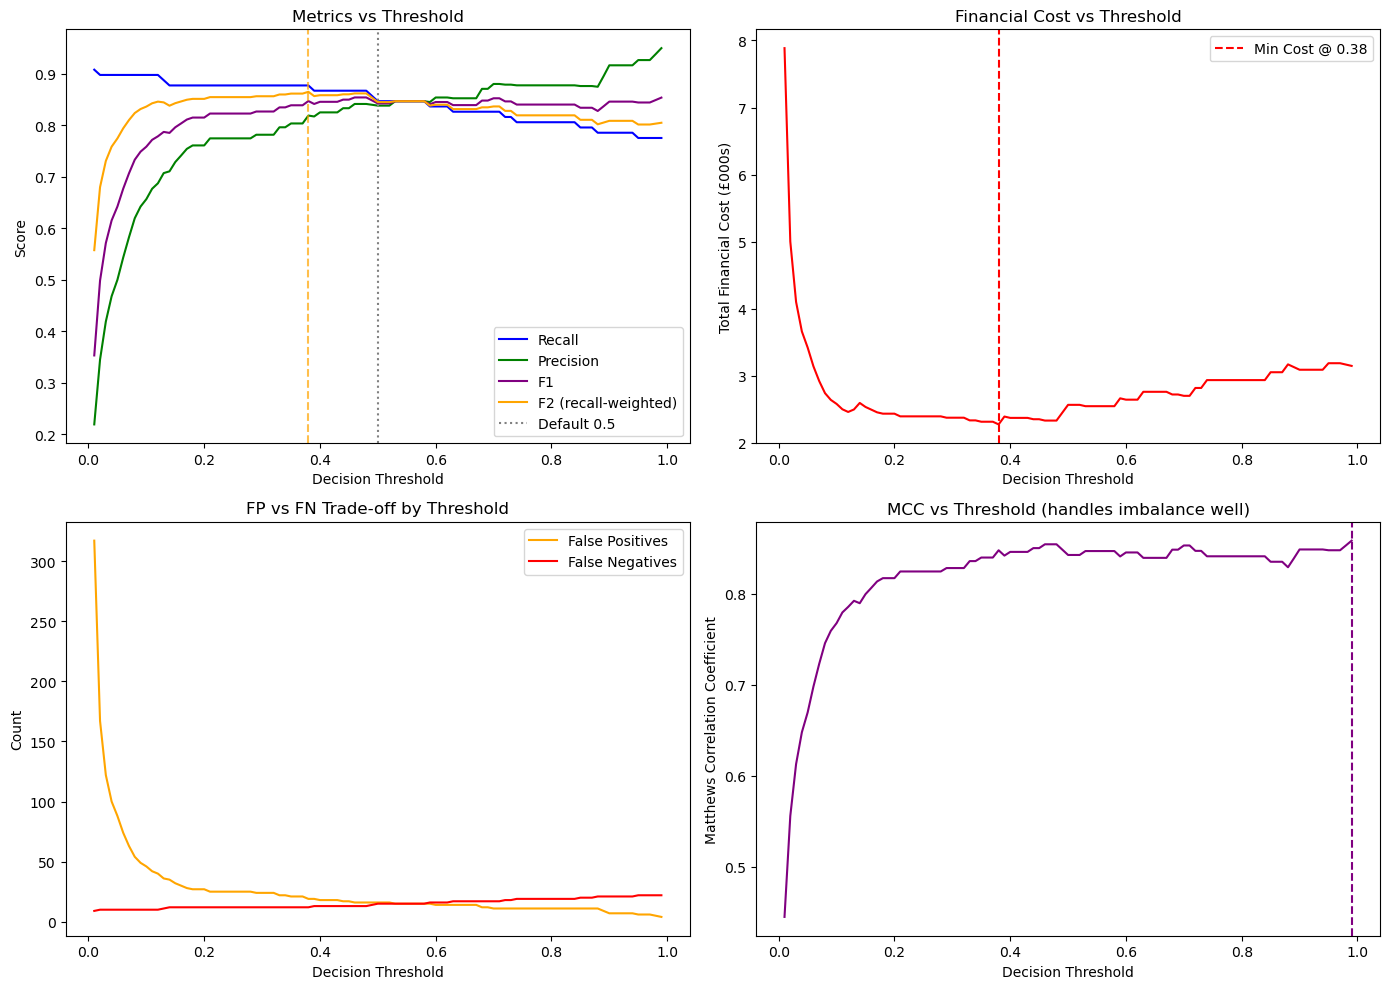

In [ ]:
# To Find optimal threshold for business cost minimization

print("\n" + "="*60)
print("SECTION 10: THRESHOLD OPTIMIZATION — COST-MINIMIZING")
print("="*60)

# Use best supervised model (default RF for demonstration)
best_model_name = max(sup_results, key=lambda k: sup_results[k]['pr_auc'])
best_proba      = models_supervised[best_model_name]['proba']

print(f"\nUsing: {best_model_name}")

thresholds_to_test = np.arange(0.01, 1.0, 0.01)
threshold_results  = []

for thresh in thresholds_to_test:
    preds = (best_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    cost = (fn * FALSE_NEGATIVE_COST +
            fp * FALSE_POSITIVE_COST +
            (tp + fp) * INVESTIGATION_COST)

    threshold_results.append({
        'Threshold': thresh,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Precision':  precision_score(y_test, preds, zero_division=0),
        'Recall':     recall_score(y_test, preds),
        'F1':         f1_score(y_test, preds, zero_division=0),
        'F2':         fbeta_score(y_test, preds, beta=2, zero_division=0),
        'MCC':        matthews_corrcoef(y_test, preds),
        'Total_Cost': cost
    })

thresh_df   = pd.DataFrame(threshold_results)
best_cost_thresh = thresh_df.loc[thresh_df['Total_Cost'].idxmin(), 'Threshold']
best_f2_thresh   = thresh_df.loc[thresh_df['F2'].idxmax(), 'Threshold']
best_f1_thresh   = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']

print(f"\nOptimal Thresholds:")
print(f"  Cost-minimizing threshold: {best_cost_thresh:.2f}")
print(f"  F2-maximizing threshold:   {best_f2_thresh:.2f}")
print(f"  F1-maximizing threshold:   {best_f1_thresh:.2f}")
print(f"  Default threshold (0.5):   0.50")

# Compare at each threshold
for thresh_name, thresh_val in [
    ('Default (0.5)',   0.5),
    ('F1-optimal',      best_f1_thresh),
    ('F2-optimal',      best_f2_thresh),
    ('Cost-optimal',    best_cost_thresh)
]:
    row = thresh_df[thresh_df['Threshold'].round(2) == round(thresh_val, 2)]
    if not row.empty:
        row = row.iloc[0]
        print(f"\n  [{thresh_name}] threshold={thresh_val:.2f}")
        print(f"    Recall={row['Recall']:.3f} | Precision={row['Precision']:.3f} | "
              f"F2={row['F2']:.3f} | Cost=£{row['Total_Cost']:,.2f}")

# Plot threshold analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(thresh_df['Threshold'], thresh_df['Recall'],    label='Recall', color='blue')
axes[0, 0].plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', color='green')
axes[0, 0].plot(thresh_df['Threshold'], thresh_df['F1'],        label='F1', color='purple')
axes[0, 0].plot(thresh_df['Threshold'], thresh_df['F2'],        label='F2 (recall-weighted)', color='orange')
axes[0, 0].axvline(best_f2_thresh, color='orange', linestyle='--', alpha=0.7)
axes[0, 0].axvline(0.5, color='grey', linestyle=':', label='Default 0.5')
axes[0, 0].set_xlabel('Decision Threshold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Metrics vs Threshold')
axes[0, 0].legend()

axes[0, 1].plot(thresh_df['Threshold'], thresh_df['Total_Cost']/1000, color='red')
axes[0, 1].axvline(best_cost_thresh, color='red', linestyle='--',
                    label=f'Min Cost @ {best_cost_thresh:.2f}')
axes[0, 1].set_xlabel('Decision Threshold')
axes[0, 1].set_ylabel('Total Financial Cost (£000s)')
axes[0, 1].set_title('Financial Cost vs Threshold')
axes[0, 1].legend()

axes[1, 0].plot(thresh_df['Threshold'], thresh_df['FP'], label='False Positives', color='orange')
axes[1, 0].plot(thresh_df['Threshold'], thresh_df['FN'], label='False Negatives', color='red')
axes[1, 0].set_xlabel('Decision Threshold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('FP vs FN Trade-off by Threshold')
axes[1, 0].legend()

axes[1, 1].plot(thresh_df['Threshold'], thresh_df['MCC'], color='purple')
axes[1, 1].axvline(thresh_df.loc[thresh_df['MCC'].idxmax(), 'Threshold'],
                    color='purple', linestyle='--')
axes[1, 1].set_xlabel('Decision Threshold')
axes[1, 1].set_ylabel('Matthews Correlation Coefficient')
axes[1, 1].set_title('MCC vs Threshold (handles imbalance well)')

plt.tight_layout()
plt.savefig('output/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()




SECTION 11: COST-SENSITIVE CONFUSION MATRIX

MODEL: Logistic Regression

  CLASSIFICATION METRICS:
    PR-AUC:     0.7107  ← Primary metric
    ROC-AUC:    0.9713
    F2 Score:   0.1359  ← Recall-weighted
    MCC:        0.1632  ← Handles imbalance
    Precision:  0.0308
    Recall:     0.9184

  CONFUSION MATRIX (Counts):
    True Negatives  (TN): 54,034  — Correctly blocked fraud
    False Positives (FP): 2,830  — Legitimate blocked incorrectly
    False Negatives (FN): 8  — MISSED FRAUD ← Critical
    True Positives  (TP): 90  — Fraud correctly caught

  FINANCIAL IMPACT:
    Fraud missed (FN × £122.21):     £    977.68
    False alarms (FP × £15.00):      £ 42,450.00
    Investigation cost:               £ 14,600.00
    ─────────────────────────────────────────────
    TOTAL COST:                       £ 58,027.68
    Max possible loss (no detection): £ 11,976.58
    SAVINGS vs no detection:          £ 10,998.90
    Fraud detection rate:             91.8%

MODEL: Random Forest

  

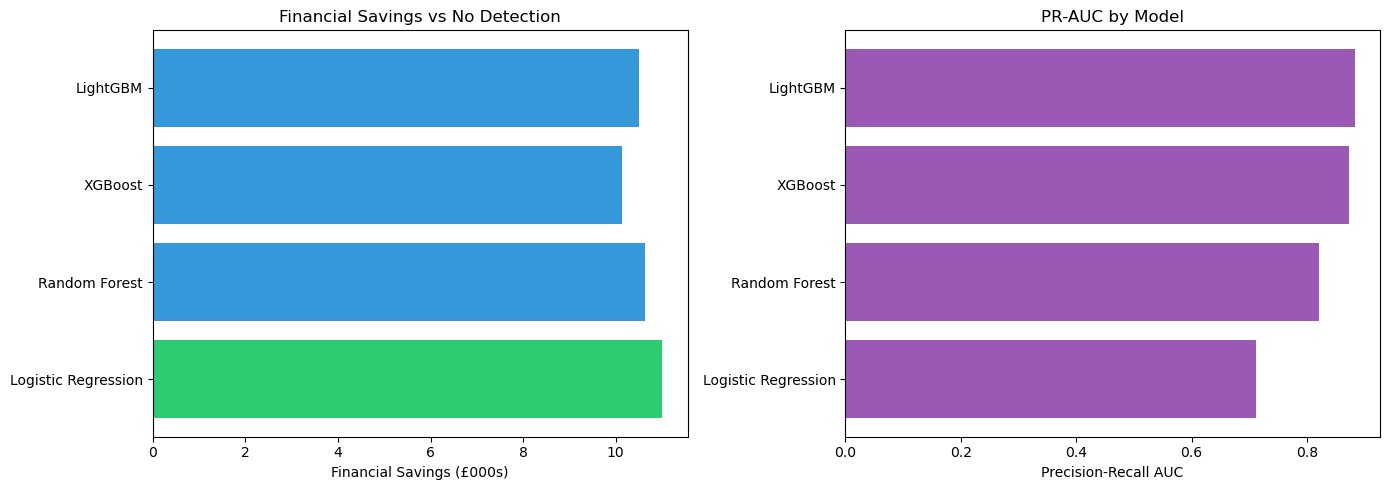

In [ ]:
print("\n" + "="*60)
print("SECTION 11: COST-SENSITIVE CONFUSION MATRIX")
print("="*60)

def cost_sensitive_report(y_true, y_pred, y_proba, model_name,
                           fn_cost=FALSE_NEGATIVE_COST,
                           fp_cost=FALSE_POSITIVE_COST,
                           inv_cost=INVESTIGATION_COST):
    """Full cost-sensitive evaluation report."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = len(y_true)

    # Financial calculations
    fraud_loss     = fn * fn_cost
    fp_cost_total  = fp * fp_cost
    inv_cost_total = (tp + fp) * inv_cost
    total_cost     = fraud_loss + fp_cost_total + inv_cost_total

    # Maximum possible loss (catching nothing)
    max_possible_loss = y_true.sum() * fn_cost

    # Savings vs doing nothing
    savings = max_possible_loss - fraud_loss

    pr_auc  = average_precision_score(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    mcc     = matthews_corrcoef(y_true, y_pred)
    f2      = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

    print(f"\n{'='*55}")
    print(f"MODEL: {model_name}")
    print(f"{'='*55}")
    print(f"\n  CLASSIFICATION METRICS:")
    print(f"    PR-AUC:     {pr_auc:.4f}  ← Primary metric")
    print(f"    ROC-AUC:    {roc_auc:.4f}")
    print(f"    F2 Score:   {f2:.4f}  ← Recall-weighted")
    print(f"    MCC:        {mcc:.4f}  ← Handles imbalance")
    print(f"    Precision:  {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"    Recall:     {recall_score(y_true, y_pred):.4f}")

    print(f"\n  CONFUSION MATRIX (Counts):")
    print(f"    True Negatives  (TN): {tn:,}  — Correctly blocked fraud")
    print(f"    False Positives (FP): {fp:,}  — Legitimate blocked incorrectly")
    print(f"    False Negatives (FN): {fn:,}  — MISSED FRAUD ← Critical")
    print(f"    True Positives  (TP): {tp:,}  — Fraud correctly caught")

    print(f"\n  FINANCIAL IMPACT:")
    print(f"    Fraud missed (FN × £{fn_cost:.2f}):     £{fraud_loss:>10,.2f}")
    print(f"    False alarms (FP × £{fp_cost:.2f}):      £{fp_cost_total:>10,.2f}")
    print(f"    Investigation cost:               £{inv_cost_total:>10,.2f}")
    print(f"    ─────────────────────────────────────────────")
    print(f"    TOTAL COST:                       £{total_cost:>10,.2f}")
    print(f"    Max possible loss (no detection): £{max_possible_loss:>10,.2f}")
    print(f"    SAVINGS vs no detection:          £{savings:>10,.2f}")
    print(f"    Fraud detection rate:             {tp/(tp+fn)*100:.1f}%")

    return {
        'model': model_name, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'pr_auc': pr_auc, 'roc_auc': roc_auc, 'f2': f2, 'mcc': mcc,
        'total_cost': total_cost, 'savings': savings
    }

# Apply cost-sensitive evaluation to all supervised models
all_cost_results = []
for name, m in models_supervised.items():
    optimal_thresh = best_f2_thresh
    preds = (m['proba'] >= optimal_thresh).astype(int)
    result = cost_sensitive_report(y_test, preds, m['proba'], name)
    all_cost_results.append(result)

cost_df = pd.DataFrame(all_cost_results)
print(f"\n\nFINAL COST COMPARISON (using F2-optimal threshold):")
print(cost_df[['model', 'pr_auc', 'f2', 'mcc', 'total_cost', 'savings']].to_string(index=False))

# Visualize cost comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ECC71' if s == cost_df['savings'].max() else '#3498DB'
          for s in cost_df['savings']]
axes[0].barh(cost_df['model'], cost_df['savings']/1000, color=colors)
axes[0].set_xlabel('Financial Savings (£000s)')
axes[0].set_title('Financial Savings vs No Detection')

axes[1].barh(cost_df['model'], cost_df['pr_auc'], color='#9B59B6')
axes[1].set_xlabel('Precision-Recall AUC')
axes[1].set_title('PR-AUC by Model')

plt.tight_layout()
plt.savefig('output/cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



SECTION 12: PRECISION-RECALL & ROC CURVES


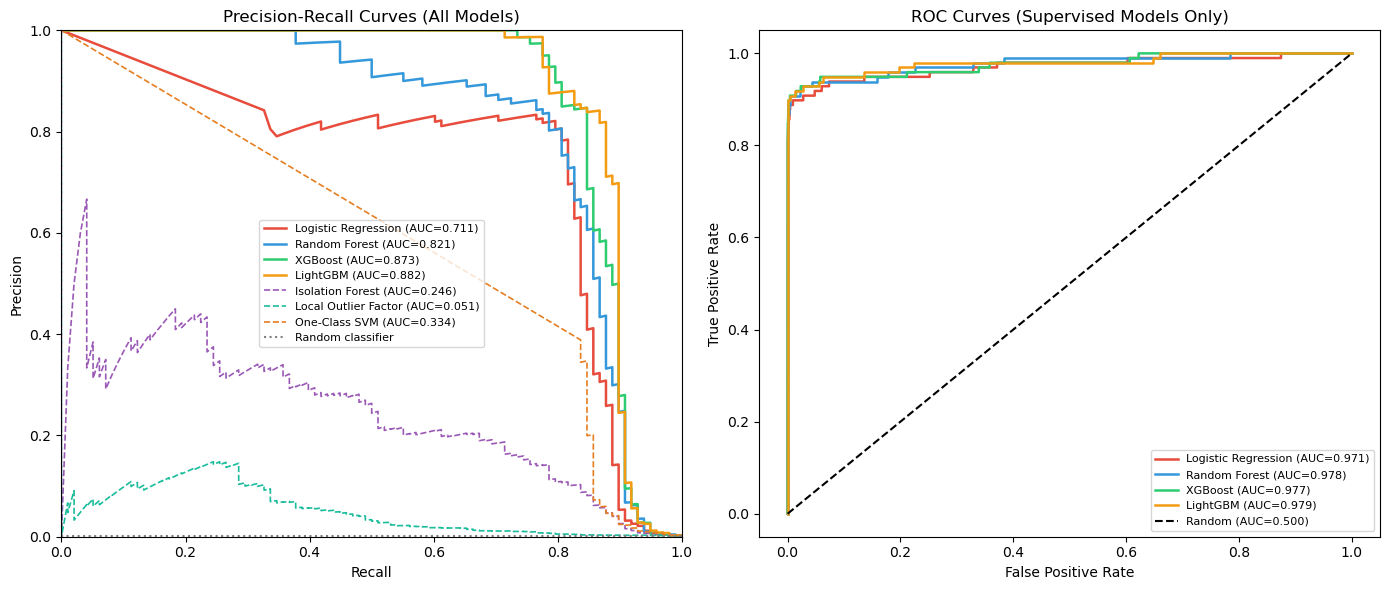


Key insight: PR curve is more informative than ROC for imbalanced data
ROC-AUC can be misleadingly high because TN dominates the denominator


In [ ]:
print("\n" + "="*60)
print("SECTION 12: PRECISION-RECALL & ROC CURVES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_list = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12',
               '#9B59B6', '#1ABC9C', '#E67E22']

# PR Curves
for i, (name, m) in enumerate(models_supervised.items()):
    prec_c, rec_c, _ = precision_recall_curve(y_test, m['proba'])
    pr_auc = average_precision_score(y_test, m['proba'])
    axes[0].plot(rec_c, prec_c, color=colors_list[i % len(colors_list)],
                 label=f"{name} (AUC={pr_auc:.3f})", linewidth=1.8)

# Add unsupervised models to PR curve
for i, (name, m) in enumerate(models_unsupervised.items()):
    prec_c, rec_c, _ = precision_recall_curve(y_test, m['scores'])
    pr_auc = average_precision_score(y_test, m['scores'])
    axes[0].plot(rec_c, prec_c, linestyle='--',
                 color=colors_list[(i+4) % len(colors_list)],
                 label=f"{name} (AUC={pr_auc:.3f})", linewidth=1.2)

axes[0].axhline(fraud_rate, color='grey', linestyle=':', label='Random classifier')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves (All Models)')
axes[0].legend(fontsize=8)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ROC Curves
for i, (name, m) in enumerate(models_supervised.items()):
    fpr, tpr, _ = roc_curve(y_test, m['proba'])
    roc_auc = roc_auc_score(y_test, m['proba'])
    axes[1].plot(fpr, tpr, color=colors_list[i % len(colors_list)],
                 label=f"{name} (AUC={roc_auc:.3f})", linewidth=1.8)

axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (Supervised Models Only)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nKey insight: PR curve is more informative than ROC for imbalanced data")
print("ROC-AUC can be misleadingly high because TN dominates the denominator")


In [ ]:
print("\n" + "="*60)
print("SECTION 13: DETECTION PHILOSOPHY COMPARISON")
print("="*60)

comparison = {
    'Aspect': [
        'Training Data Required',
        'Interpretability',
        'Novel Fraud Detection',
        'Latency (real-time)',
        'Maintenance',
        'False Positive Rate',
        'Best Use Case',
        'When to Use'
    ],
    'Rule-Based': [
        'None',
        'Full (explicit rules)',
        'Poor (misses new patterns)',
        'Microseconds',
        'High (manual rule updates)',
        'High (rigid thresholds)',
        'Compliance/Regulatory context',
        'When you need full explainability'
    ],
    'ML (Isolation Forest/RF)': [
        'Historical labeled/unlabeled',
        'Medium (feature importance)',
        'Good (learns patterns)',
        'Milliseconds',
        'Medium (periodic retraining)',
        'Tunable via threshold',
        'Production fraud systems',
        'When you have labeled data'
    ],
    'Deep Learning (Autoencoder)': [
        'Large unlabeled data',
        'Low (black box)',
        'Excellent (learns representations)',
        'Tens of milliseconds',
        'Low (self-learns)',
        'Lower (better representation)',
        'High-volume card fraud',
        'When labels are scarce'
    ]
}

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))



SECTION 13: DETECTION PHILOSOPHY COMPARISON
                Aspect                        Rule-Based     ML (Isolation Forest/RF)        Deep Learning (Autoencoder)
Training Data Required                              None Historical labeled/unlabeled               Large unlabeled data
      Interpretability             Full (explicit rules)  Medium (feature importance)                    Low (black box)
 Novel Fraud Detection        Poor (misses new patterns)       Good (learns patterns) Excellent (learns representations)
   Latency (real-time)                      Microseconds                 Milliseconds               Tens of milliseconds
           Maintenance        High (manual rule updates) Medium (periodic retraining)                  Low (self-learns)
   False Positive Rate           High (rigid thresholds)        Tunable via threshold      Lower (better representation)
         Best Use Case     Compliance/Regulatory context     Production fraud systems             High-volum


SECTION 14: FEATURE IMPORTANCE & EXPLAINABILITY

Top 20 Most Important Features (Random Forest):
V14                   0.1261
V14_V12_interaction   0.1037
V14_V12_interaction   0.0916
V4                    0.0848
V12                   0.0789
V10                   0.0730
V17_V14_interaction   0.0662
V17_V14_interaction   0.0636
V11                   0.0471
V17                   0.0435
V3                    0.0348
V7                    0.0211
V16                   0.0128
V2                    0.0122
V17_Amount_ratio      0.0117
V9                    0.0106
V8                    0.0100
Is_Rush_Hour          0.0090
V17_Amount_ratio      0.0088
V18                   0.0084
dtype: float64


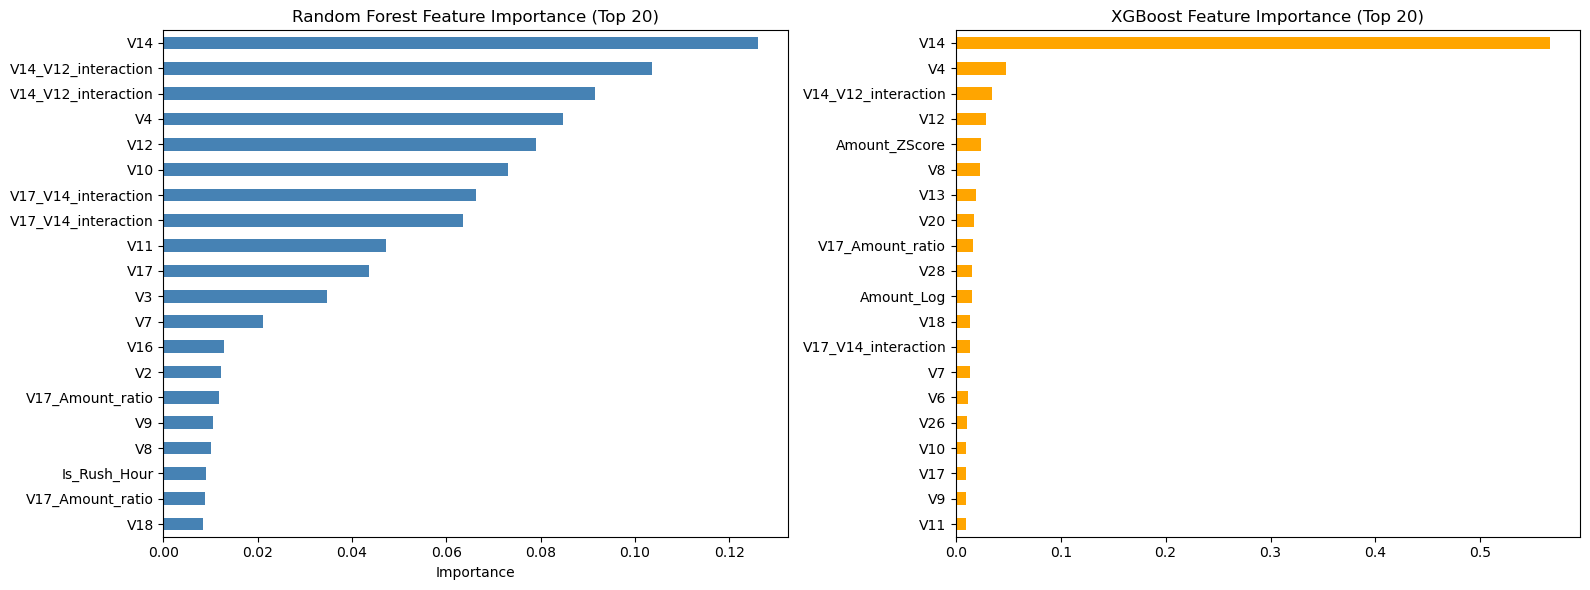

In [ ]:
print("\n" + "="*60)
print("SECTION 14: FEATURE IMPORTANCE & EXPLAINABILITY")
print("="*60)

# Random Forest Feature Importance
rf_importance = pd.Series(
    rf.feature_importances_, index=feature_cols_ml
).sort_values(ascending=False)

print("\nTop 20 Most Important Features (Random Forest):")
print(rf_importance.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importance.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance (Top 20)')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# SHAP values (if available)
if SHAP_AVAILABLE:
    explainer  = shap.TreeExplainer(rf)
    # Use small sample for speed
    sample_idx = np.random.choice(len(X_test_scaled), 200, replace=False)
    shap_values = explainer.shap_values(X_test_scaled[sample_idx])

    # shap_values[1] = fraud class
    shap_fraud = shap_values[1] if isinstance(shap_values, list) else shap_values

    # SHAP summary plot
    plt.sca(axes[1])
    shap.summary_plot(
        shap_fraud,
        pd.DataFrame(X_test_scaled[sample_idx], columns=feature_cols_ml),
        max_display=15,
        show=False,
        plot_type='bar'
    )
    axes[1].set_title('SHAP Feature Importance (Fraud Class)')
else:
    # XGBoost importance as fallback
    if XGB_AVAILABLE:
        xgb_imp = pd.Series(
            xgb_model.feature_importances_, index=feature_cols_ml
        ).sort_values(ascending=False)
        xgb_imp.head(20).plot(kind='barh', ax=axes[1], color='orange')
        axes[1].set_title('XGBoost Feature Importance (Top 20)')
        axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print("\n" + "="*60)
print("SECTION 15: REAL-TIME TRANSACTION SCORING SIMULATION")
print("="*60)

def score_transaction(transaction_dict, model, scaler, feature_cols,
                       threshold=0.5):
    """
    Score a single incoming transaction in real-time.
    Returns risk score, prediction, and decision.
    """
    # Build feature vector
    txn_df = pd.DataFrame([transaction_dict])

    # Engineer features
    txn_df['Hour']          = (txn_df['Time'] // 3600) % 24
    txn_df['Is_Night']      = ((txn_df['Hour'] >= 22) | (txn_df['Hour'] <= 5)).astype(int)
    txn_df['Is_Rush_Hour']  = txn_df['Hour'].between(7, 9).astype(int)
    txn_df['Amount_Log']    = np.log1p(txn_df['Amount'])
    txn_df['Is_Round_Amount']   = (txn_df['Amount'] % 1 == 0).astype(int)
    txn_df['Is_Small_Amount']   = (txn_df['Amount'] < 1).astype(int)
    txn_df['Amount_ZScore']     = 0  # Would need rolling stats in production
    txn_df['V17_V14_interaction']= txn_df['V17'] * txn_df['V14']
    txn_df['V17_Amount_ratio']   = txn_df['V17'] / (txn_df['Amount'] + 1)
    txn_df['V14_V12_interaction']= txn_df['V14'] * txn_df['V12']
    txn_df['Day_Number']         = 0

    X_txn = txn_df[feature_cols].fillna(0)
    X_txn_scaled = scaler.transform(X_txn)

    t_start    = time.time()
    proba      = model.predict_proba(X_txn_scaled)[0][1]
    latency_ms = (time.time() - t_start) * 1000

    decision = 'BLOCK'   if proba >= threshold * 1.5 else \
               'REVIEW'  if proba >= threshold        else \
               'APPROVE'

    return {
        'fraud_probability': round(proba, 4),
        'decision':          decision,
        'latency_ms':        round(latency_ms, 3),
        'risk_tier':         'HIGH' if proba > 0.7 else
                             'MEDIUM' if proba > 0.3 else 'LOW'
    }

# Simulate 20 incoming transactions (mix of real test set examples)
print("\nSimulating real-time transaction scoring...\n")
print(f"{'TXN#':>5} {'Amount':>8} {'Hour':>5} {'Actual':>8} "
      f"{'Fraud_Prob':>11} {'Decision':>10} {'Risk':>7} {'Latency':>9}")
print("-" * 75)

# Sample some transactions with known labels for demo
sample_legit = df_eng[df_eng['Class'] == 0].sample(15, random_state=42)
sample_fraud  = df_eng[df_eng['Class'] == 1].sample(5, random_state=42)
sim_batch     = pd.concat([sample_legit, sample_fraud]).sample(frac=1, random_state=99)

sim_results = []
v_cols = [c for c in df.columns if c.startswith('V')]
for i, (_, row) in enumerate(sim_batch.iterrows()):
    txn = row[v_cols + ['Amount', 'Time']].to_dict()
    result = score_transaction(txn, rf, scaler, feature_cols_ml,
                                threshold=best_f2_thresh)
    actual = 'FRAUD' if row['Class'] == 1 else 'LEGIT'
    hour   = int((row['Time'] // 3600) % 24)

    status = ('✅ CORRECT' if (result['decision'] in ['BLOCK','REVIEW']
                               and actual == 'FRAUD') or
                              (result['decision'] == 'APPROVE'
                               and actual == 'LEGIT') else '❌ WRONG')

    print(f"{i+1:>5} {row['Amount']:>8.2f} {hour:>5} {actual:>8} "
          f"{result['fraud_probability']:>11.4f} {result['decision']:>10} "
          f"{result['risk_tier']:>7} {result['latency_ms']:>7.2f}ms  {status}")

    sim_results.append({**result, 'actual': actual, 'amount': row['Amount']})

sim_df = pd.DataFrame(sim_results)
print(f"\nSimulation Summary:")
print(f"  Avg latency:        {sim_df['latency_ms'].mean():.2f}ms per transaction")
print(f"  Max latency:        {sim_df['latency_ms'].max():.2f}ms")
print(f"  APPROVE decisions:  {(sim_df['decision']=='APPROVE').sum()}")
print(f"  REVIEW decisions:   {(sim_df['decision']=='REVIEW').sum()}")
print(f"  BLOCK decisions:    {(sim_df['decision']=='BLOCK').sum()}")



SECTION 15: REAL-TIME TRANSACTION SCORING SIMULATION

Simulating real-time transaction scoring...

 TXN#   Amount  Hour   Actual  Fraud_Prob   Decision    Risk   Latency
---------------------------------------------------------------------------
    1     1.98    18    LEGIT      0.0207    APPROVE     LOW   34.67ms  ✅ CORRECT
    2    99.99     7    FRAUD      0.9997      BLOCK    HIGH   28.78ms  ✅ CORRECT
    3    97.65    11    LEGIT      0.0288    APPROVE     LOW   31.47ms  ✅ CORRECT
    4   108.22    22    LEGIT      0.0083    APPROVE     LOW   30.06ms  ✅ CORRECT
    5     0.76    22    LEGIT      0.1352    APPROVE     LOW   29.93ms  ✅ CORRECT
    6    49.83     3    LEGIT      0.0125    APPROVE     LOW   29.71ms  ✅ CORRECT
    7    20.30    11    LEGIT      0.0168    APPROVE     LOW   32.45ms  ✅ CORRECT
    8     1.00     6    FRAUD      0.9997      BLOCK    HIGH   30.27ms  ✅ CORRECT
    9    38.76     1    FRAUD      0.9520      BLOCK    HIGH   29.26ms  ✅ CORRECT
   10    35.00 

In [ ]:
print("\n" + "="*60)
print("SECTION 16: STRATIFIED CROSS-VALIDATION")
print("="*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
}
if XGB_AVAILABLE:
    cv_models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=100, scale_pos_weight=scale_pos,
        random_state=42, verbosity=0, n_jobs=-1)

print(f"\n5-Fold Stratified Cross-Validation (PR-AUC):")
print(f"{'Model':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=skf, scoring='average_precision', n_jobs=-1
    )
    print(f"{name:<25} {scores.mean():>8.4f} {scores.std():>8.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")



SECTION 16: STRATIFIED CROSS-VALIDATION

5-Fold Stratified Cross-Validation (PR-AUC):
Model                         Mean      Std      Min      Max
------------------------------------------------------------
Logistic Regression         0.7621   0.0419   0.7105   0.8314
Random Forest               0.8319   0.0459   0.7784   0.8989
XGBoost                     0.8408   0.0373   0.8015   0.8970



SECTION 17: LEARNING CURVES — BIAS-VARIANCE ANALYSIS


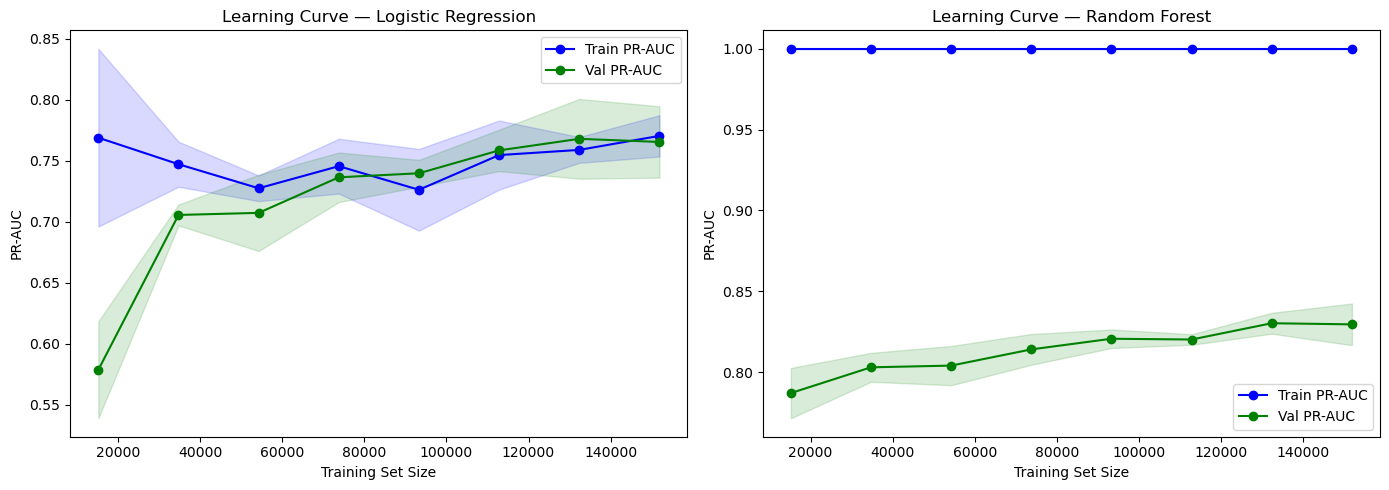

In [ ]:
print("\n" + "="*60)
print("SECTION 17: LEARNING CURVES — BIAS-VARIANCE ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, model) in enumerate(list(cv_models.items())[:2]):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='average_precision',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    axes[i].plot(train_sizes, train_scores.mean(axis=1),
                  'o-', color='blue', label='Train PR-AUC')
    axes[i].fill_between(train_sizes,
                          train_scores.mean(axis=1) - train_scores.std(axis=1),
                          train_scores.mean(axis=1) + train_scores.std(axis=1),
                          alpha=0.15, color='blue')
    axes[i].plot(train_sizes, test_scores.mean(axis=1),
                  'o-', color='green', label='Val PR-AUC')
    axes[i].fill_between(train_sizes,
                          test_scores.mean(axis=1) - test_scores.std(axis=1),
                          test_scores.mean(axis=1) + test_scores.std(axis=1),
                          alpha=0.15, color='green')
    axes[i].set_xlabel('Training Set Size')
    axes[i].set_ylabel('PR-AUC')
    axes[i].set_title(f'Learning Curve — {name}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('output/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()



SECTION 18: FRAUD AMOUNT DEEP ANALYSIS

Fraud Amount Statistics:
count    492.0000
mean     122.2113
std      256.6833
min        0.0000
25%        1.0000
50%        9.2500
75%      105.8900
max     2125.8700
Name: Amount, dtype: float64

Legitimate Amount Statistics:
count   284315.0000
mean        88.2910
std        250.1051
min          0.0000
25%          5.6500
50%         22.0000
75%         77.0500
max      25691.1600
Name: Amount, dtype: float64

Mann-Whitney U Test (Fraud vs Legit Amount):
  Statistic: 61833399.00
  P-value:   0.000009
  Result: Significantly different


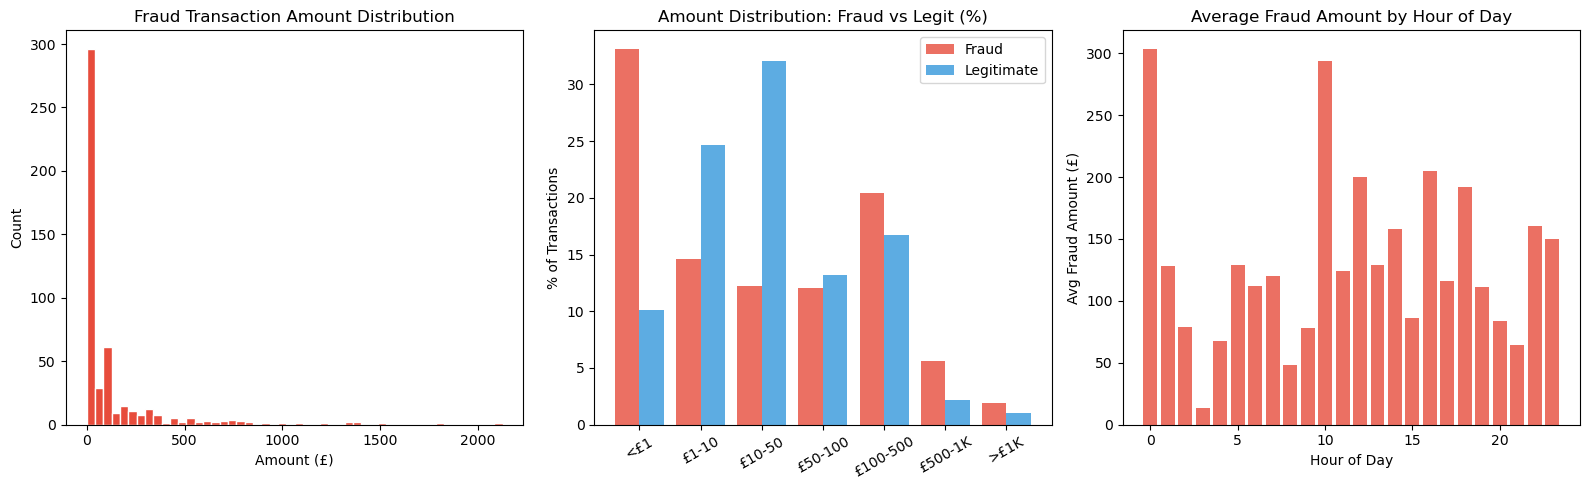

In [ ]:
print("\n" + "="*60)
print("SECTION 18: FRAUD AMOUNT DEEP ANALYSIS")
print("="*60)

fraud_df = df[df['Class'] == 1].copy()
legit_df = df[df['Class'] == 0].copy()

print(f"\nFraud Amount Statistics:")
print(fraud_df['Amount'].describe())
print(f"\nLegitimate Amount Statistics:")
print(legit_df['Amount'].describe())

# Mann-Whitney test — are fraud amounts significantly different?
stat, p = mannwhitneyu(fraud_df['Amount'], legit_df['Amount'])
print(f"\nMann-Whitney U Test (Fraud vs Legit Amount):")
print(f"  Statistic: {stat:.2f}")
print(f"  P-value:   {p:.6f}")
print(f"  Result: {'Significantly different' if p < 0.05 else 'Not significant'}")

# Fraud amount distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(fraud_df['Amount'], bins=50, color='#E74C3C', edgecolor='white')
axes[0].set_title('Fraud Transaction Amount Distribution')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Count')

# Fraud by amount bucket
buckets = [0, 1, 10, 50, 100, 500, 1000, float('inf')]
labels  = ['<£1', '£1-10', '£10-50', '£50-100', '£100-500', '£500-1K', '>£1K']
fraud_df['Amount_Bucket'] = pd.cut(fraud_df['Amount'], bins=buckets, labels=labels)
legit_df['Amount_Bucket'] = pd.cut(legit_df['Amount'], bins=buckets, labels=labels)

fraud_bucket = fraud_df['Amount_Bucket'].value_counts().sort_index()
legit_bucket = legit_df['Amount_Bucket'].value_counts().sort_index()

x = np.arange(len(labels))
axes[1].bar(x - 0.2, fraud_bucket.values / fraud_bucket.sum() * 100,
            0.4, label='Fraud', color='#E74C3C', alpha=0.8)
axes[1].bar(x + 0.2, legit_bucket.values / legit_bucket.sum() * 100,
            0.4, label='Legitimate', color='#3498DB', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30)
axes[1].set_ylabel('% of Transactions')
axes[1].set_title('Amount Distribution: Fraud vs Legit (%)')
axes[1].legend()

# Hourly fraud amount
hourly_amount = df[df['Class']==1].groupby('Hour')['Amount'].mean()
axes[2].bar(hourly_amount.index, hourly_amount.values, color='#E74C3C', alpha=0.8)
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg Fraud Amount (£)')
axes[2].set_title('Average Fraud Amount by Hour of Day')

plt.tight_layout()
plt.savefig('output/fraud_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
print("\n" + "="*60)
print("SECTION 19: HYPOTHESIS TESTING — FRAUD PATTERN VALIDATION")
print("="*60)

# Test 1: Is night-time significantly more fraudulent?
night_fraud = df_eng[df_eng['Is_Night'] == 1]['Class']
day_fraud   = df_eng[df_eng['Is_Night'] == 0]['Class']
stat1, p1   = mannwhitneyu(night_fraud, day_fraud, alternative='greater')
night_rate  = night_fraud.mean() * 100
day_rate    = day_fraud.mean() * 100

print(f"\n── Test 1: Is night-time fraud rate higher than daytime? ──")
print(f"  Night fraud rate: {night_rate:.4f}%")
print(f"  Day fraud rate:   {day_rate:.4f}%")
print(f"  Mann-Whitney p-value: {p1:.6f}")
print(f"  Result: {'REJECT H0 — Night significantly more fraudulent' if p1 < 0.05 else 'FAIL TO REJECT H0'}")

# Test 2: Do small amounts (<£1) have higher fraud rates?
small_fraud  = df_eng[df_eng['Is_Small_Amount'] == 1]['Class']
normal_fraud = df_eng[df_eng['Is_Small_Amount'] == 0]['Class']
stat2, p2    = mannwhitneyu(small_fraud, normal_fraud, alternative='greater')
small_rate   = small_fraud.mean() * 100
normal_rate  = normal_fraud.mean() * 100

print(f"\n── Test 2: Do micro-transactions (<£1) indicate fraud testing? ──")
print(f"  Small amount fraud rate: {small_rate:.4f}%")
print(f"  Normal amount fraud rate:{normal_rate:.4f}%")
print(f"  Ratio: {small_rate/normal_rate:.1f}x more fraudulent")
print(f"  Mann-Whitney p-value: {p2:.6f}")
print(f"  Result: {'REJECT H0 — Micro-transactions significantly more fraudulent' if p2 < 0.05 else 'FAIL TO REJECT H0'}")

# Test 3: KS test on V14 — most discriminative feature
v14_fraud = df[df['Class'] == 1]['V14']
v14_legit = df[df['Class'] == 0]['V14']
stat3, p3 = ks_2samp(v14_fraud, v14_legit)

print(f"\n── Test 3: KS Test — V14 distribution (Fraud vs Legit) ──")
print(f"  Fraud V14 mean: {v14_fraud.mean():.4f}")
print(f"  Legit V14 mean: {v14_legit.mean():.4f}")
print(f"  KS Statistic:   {stat3:.4f}")
print(f"  P-value:        {p3:.10f}")
print(f"  Result: {'REJECT H0 — V14 distributions are significantly different' if p3 < 0.05 else 'FAIL TO REJECT H0'}")
print(f"  V14 is the single most discriminative feature for fraud detection")



SECTION 19: HYPOTHESIS TESTING — FRAUD PATTERN VALIDATION

── Test 1: Is night-time fraud rate higher than daytime? ──
  Night fraud rate: 0.3061%
  Day fraud rate:   0.1441%
  Mann-Whitney p-value: 0.000000
  Result: REJECT H0 — Night significantly more fraudulent

── Test 2: Do micro-transactions (<£1) indicate fraud testing? ──
  Small amount fraud rate: 0.4047%
  Normal amount fraud rate:0.1582%
  Ratio: 2.6x more fraudulent
  Mann-Whitney p-value: 0.000000
  Result: REJECT H0 — Micro-transactions significantly more fraudulent

── Test 3: KS Test — V14 distribution (Fraud vs Legit) ──
  Fraud V14 mean: -6.9717
  Legit V14 mean: 0.0121
  KS Statistic:   0.8428
  P-value:        0.0000000000
  Result: REJECT H0 — V14 distributions are significantly different
  V14 is the single most discriminative feature for fraud detection


In [ ]:
print("\n" + "="*60)
print("SECTION 20: FINAL MODEL RECOMMENDATION REPORT")
print("="*60)

best_model_result = cost_df.loc[cost_df['savings'].idxmax()]

print(f"""
══════════════════════════════════════════════════════════════
         FRAUD DETECTION — EXECUTIVE SUMMARY REPORT          
══════════════════════════════════════════════════════════════
Dataset:       284,807 transactions | 492 fraud cases      
Fraud Rate:    0.17% (severely imbalanced)                 
══════════════════════════════════════════════════════════════
RECOMMENDED MODEL: {best_model_result['model']:<38}
PR-AUC:        {best_model_result['pr_auc']:.4f}                                    
F2 Score:      {best_model_result['f2']:.4f}                                    
MCC:           {best_model_result['mcc']:.4f}                                    
Financial Savings vs No Detection: £{best_model_result['savings']:,.2f}              
══════════════════════════════════════════════════════════════
KEY DESIGN DECISIONS:                                       
1. Used PR-AUC (not accuracy) — handles imbalance          
2. Used RobustScaler (not StandardScaler) — outliers       
3. Used SMOTE for training resampling                       
4. Optimized threshold for F2 (recall > precision)         
5. Cost matrix: FN=£{FALSE_NEGATIVE_COST:.2f}, FP=£{FALSE_POSITIVE_COST:.2f}                          
══════════════════════════════════════════════════════════════
PRODUCTION RECOMMENDATIONS:                                 
• Deploy with F2-optimal threshold: {best_f2_thresh:.2f}               
• Retrain monthly on new fraud patterns                     
• Monitor data drift on V1-V28 features                    
• Implement 3-tier decision: APPROVE/REVIEW/BLOCK          
• Log all REVIEW decisions for analyst investigation       
══════════════════════════════════════════════════════════════
""")

# Save outputs
df_eng[feature_cols_ml + ['Class']].to_csv('output/engineered_features.csv', index=False)
thresh_df.to_csv('output/threshold_analysis.csv', index=False)
cost_df.to_csv('output/model_cost_comparison.csv', index=False)
sim_df.to_csv('output/realtime_simulation.csv', index=False)

print("\nAll outputs saved to /output/ directory")
print("Files: engineered_features.csv, threshold_analysis.csv,")
print("       model_cost_comparison.csv, realtime_simulation.csv")
print("\n" + "="*60)
print("FRAUD DETECTION ANALYSIS COMPLETE")
print("="*60)



SECTION 20: FINAL MODEL RECOMMENDATION REPORT

══════════════════════════════════════════════════════════════
         FRAUD DETECTION — EXECUTIVE SUMMARY REPORT          
══════════════════════════════════════════════════════════════
Dataset:       284,807 transactions | 492 fraud cases      
Fraud Rate:    0.17% (severely imbalanced)                 
══════════════════════════════════════════════════════════════
RECOMMENDED MODEL: Logistic Regression                   
PR-AUC:        0.7107                                    
F2 Score:      0.1359                                    
MCC:           0.1632                                    
Financial Savings vs No Detection: £10,998.90              
══════════════════════════════════════════════════════════════
KEY DESIGN DECISIONS:                                       
1. Used PR-AUC (not accuracy) — handles imbalance          
2. Used RobustScaler (not StandardScaler) — outliers       
3. Used SMOTE for training resampling        